In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
from scipy.stats import ttest_ind  # Hypothesis Testing
import scipy.stats as stats

warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [2]:
username = "root"
password = "$Maersk282"
host = "127.0.0.1"
port = "3306"
database = "vendor_performance_db"



In [3]:

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}"
)

In [4]:
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", engine)

In [5]:
# Filter data by removing inconsistencies

df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", engine)

In [6]:
df.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
count,8565.000000,8565.000000,8565.000000,8565.000000,8565.000000,8565.000000,8.565000e+03,8565.000000,8.565000e+03,8565.000000,8565.000000,8565.000000,8.565000e+03,8.565000e+03,8565.000000,8565.000000
mean,10107.041331,17614.046468,21.779365,32.295213,864.406480,3771.571395,3.588309e+04,3748.547577,5.153628e+04,22756.625624,2182.553748,63443.971800,1.565320e+04,3.871847e+01,2.031894,2.991193
std,17634.685420,12945.503736,81.185007,112.414374,724.230365,12276.310633,1.367156e+05,12125.055208,1.860615e+05,49303.003032,12225.226634,62267.459516,5.100149e+04,2.137685e+01,6.685874,9.386758
min,2.000000,58.000000,0.360000,0.490000,50.000000,1.000000,7.100000e-01,1.000000,1.980000e+00,0.990000,0.100000,0.090000,2.842171e-14,1.367480e-14,0.428571,1.000000
25%,3664.000000,5376.000000,6.660000,9.990000,750.000000,42.000000,5.454900e+02,62.000000,1.349850e+03,584.610000,9.450000,14836.570000,4.914700e+02,2.592894e+01,0.945234,1.350055
50%,7153.000000,17601.000000,10.060000,14.990000,750.000000,431.000000,5.017200e+03,490.000000,8.482220e+03,4549.650000,84.760000,55551.820000,3.085260e+03,3.335835e+01,1.000000,1.500563
75%,9552.000000,24935.000000,17.850000,25.990000,750.000000,2666.000000,2.660061e+04,2675.000000,4.061305e+04,22595.120000,594.460000,89286.270000,1.245789e+04,4.412051e+01,1.120643,1.789565
max,201359.000000,90631.000000,3352.930000,4559.990000,20000.000000,337660.000000,3.811252e+06,334939.000000,5.101920e+06,672819.310000,368242.800000,257032.070000,1.290668e+06,9.971666e+01,274.500000,352.928571


### _Linear Regression part - needs more deeper analysis_

In [7]:

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


# df = df.replace([np.inf, -np.inf], np.nan).dropna()

X = df[['PurchasePrice', 'ActualPrice', 'Volume',
      'TotalPurchaseQuantity', 'FreightCost',
      'TotalExciseTax', 'StockTurnover']]
y = df['GrossProfit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test,y_pred)):,.0f}")

X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
print(ols.summary())


R²: 0.6672
RMSE: $26,165
                            OLS Regression Results                            
Dep. Variable:            GrossProfit   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     3282.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        13:24:31   Log-Likelihood:                -99409.
No. Observations:                8565   AIC:                         1.988e+05
Df Residuals:                    8557   BIC:                         1.989e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const

In [8]:
# ── Step 2: Load data and select clustering features ─────────────



cluster_features = ['ProfitMargin', 'StockTurnover', 'GrossProfit']

df_cluster = df[cluster_features].copy()

print("Shape before cleaning:", df_cluster.shape)
print("\nBasic stats before cleaning:")
print(df_cluster.describe().round(3))

Shape before cleaning: (8565, 3)

Basic stats before cleaning:
       ProfitMargin  StockTurnover  GrossProfit
count      8565.000       8565.000     8565.000
mean         38.718          2.032    15653.197
std          21.377          6.686    51001.489
min           0.000          0.429        0.000
25%          25.929          0.945      491.470
50%          33.358          1.000     3085.260
75%          44.121          1.121    12457.890
max          99.717        274.500  1290667.910


In [9]:
# ── Step 3: Clean — replace infinities and drop nulls ────────────
#
# Rows where TotalSalesQuantity is zero produce infinite or
# undefined ProfitMargin and StockTurnover values.
# These are replaced with NaN and dropped before clustering.

# df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna()

print("Shape after removing inf and null:", df_cluster.shape)

Shape after removing inf and null: (8565, 3)


In [10]:
# ── Step 4: Remove extreme outliers ─────────────────────────────
#
# Even after replacing infinities, extreme finite outliers remain.
# A ProfitMargin of -20,000 or StockTurnover of 280 are not
# genuine commercial values — they are data quality artefacts
# from near-zero sales records. These destroy clustering results
# and make visualisations unreadable.
#
# Commercial bounds applied:
# ProfitMargin: -100% to 100% (genuine percentage range)
# StockTurnover: 0 to 3 (genuine operational range)
# GrossProfit: above -500,000 (removes extreme loss outliers)

before = len(df_cluster)

df_cluster = df_cluster[
    
    (df_cluster['StockTurnover'] >=  0)      &
    (df_cluster['StockTurnover'] <=  3)      
   
]

after = len(df_cluster)

print(f"Rows before outlier removal: {before}")
print(f"Rows after outlier removal:  {after}")
print(f"Rows removed: {before - after}")
print()
print("Stats after cleaning — confirm ranges are sensible:")
print(df_cluster.describe().round(3))

Rows before outlier removal: 8565
Rows after outlier removal:  7770
Rows removed: 795

Stats after cleaning — confirm ranges are sensible:
       ProfitMargin  StockTurnover  GrossProfit
count      7770.000       7770.000     7770.000
mean         33.685          1.085    16875.584
std          15.048          0.383    53352.572
min           0.000          0.429        0.000
25%          24.942          0.934      453.638
50%          32.399          0.994     3513.880
75%          39.596          1.034    14035.927
max          83.923          3.000  1290667.910


In [11]:
# ── Step 5: Standardise features ─────────────────────────────────
#
# K-means uses Euclidean distance. Without standardisation,
# GrossProfit (in hundreds of thousands) would dominate the
# clustering entirely — ProfitMargin and StockTurnover would
# be effectively ignored due to their smaller scale.
# StandardScaler transforms each feature to mean=0, std=1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Standardisation complete.")
print(f"Shape of scaled matrix: {X_scaled.shape}")
print()

# Confirm mean ≈ 0 and std ≈ 1 after scaling
scaled_check = pd.DataFrame(
    X_scaled, columns=cluster_features
)
print("Mean per feature (should be ~0):")
print(scaled_check.mean().round(4))
print()
print("Std per feature (should be ~1):")
print(scaled_check.std().round(4))

Standardisation complete.
Shape of scaled matrix: (7770, 3)

Mean per feature (should be ~0):
ProfitMargin    -0.0
StockTurnover    0.0
GrossProfit      0.0
dtype: float64

Std per feature (should be ~1):
ProfitMargin     1.0001
StockTurnover    1.0001
GrossProfit      1.0001
dtype: float64


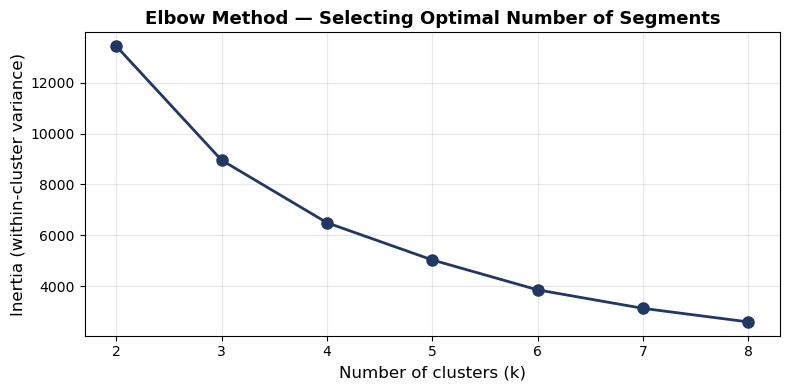

In [12]:
# ── Step 6: Elbow method ─────────────────────────────────────────
#
# Tests k=2 through k=8. Plots inertia (total within-cluster
# variance) against k. The "elbow" — where the curve bends and
# adding more clusters gives diminishing returns — indicates
# the optimal number of clusters.
# Run on the CLEANED, STANDARDISED data.

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias,
         marker='o',
         color='#1F3864',
         linewidth=2,
         markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia (within-cluster variance)', fontsize=12)
plt.title('Elbow Method — Selecting Optimal Number of Segments',
          fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### _What the elbow plot shows_
Look for the point where the curve bends — where inertia stops 
dropping sharply and begins to flatten. This is the optimal k. 
Adding clusters beyond this point gives diminishing returns in 
variance reduction. The k value is noted where bend occurs and 
is matched with silhouette score and k value obtained in this method

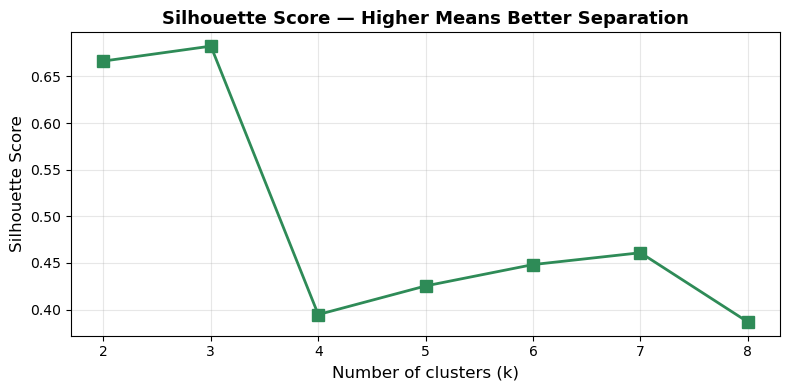

Silhouette scores per k:
  k=2:  0.6664
  k=3:  0.6825 ← highest
  k=4:  0.3946
  k=5:  0.4253
  k=6:  0.4482
  k=7:  0.4609
  k=8:  0.3867


In [13]:
# ── Step 7: Silhouette score ─────────────────────────────────────
#
# Silhouette score measures how well-separated clusters are.
# Range: -1 (poor) to 1 (perfect separation).
# Higher = clusters are more distinct and internally consistent.
# We use this alongside the elbow method — both agreeing on the
# same k gives much stronger justification than either alone.

sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores,
         marker='s',
         color='#2E8B57',
         linewidth=2,
         markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score — Higher Means Better Separation',
          fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Silhouette scores per k:")
for k, score in zip(k_range, sil_scores):
    marker = " ← highest" if score == max(sil_scores) else ""
    print(f"  k={k}:  {score:.4f}{marker}")

### Silhouette score validation
The silhouette score confirms the optimal k found in the elbow 
method. When both methods point to the same k, the cluster 
choice is well-validated. A silhouette score above 0.3 indicates 
meaningful separation.
Here k value for Silhouette score 
we will go with will be 3


In [14]:
# ── Step 8: Final k-means model ──────────────────────────────────
#
# Run the final model with the optimal k confirmed by both
# elbow and silhouette analysis.
# n_init=10 means k-means runs 10 times with different starting
# points and picks the best result — reduces sensitivity to
# random initialisation.

OPTIMAL_K = 3   # adjust if elbow/silhouette point to different k

km_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

df_cluster['Cluster_Num'] = km_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df_cluster['Cluster_Num'])
print(f"Final model — k={OPTIMAL_K}")
print(f"Silhouette score: {final_sil:.4f}")
print()
print("Cluster sizes:")
print(df_cluster['Cluster_Num'].value_counts().sort_index())

Final model — k=3
Silhouette score: 0.6825

Cluster sizes:
Cluster_Num
0     804
1    6916
2      50
Name: count, dtype: int64


In [15]:
# ── Step 9: Examine cluster means — assign business labels ───────
#
# K-means assigns numbers (0, 1, 2) — not business labels.
# We look at the mean values per cluster to understand what
# each one represents commercially, then assign names.
# This is the most important interpretive step — it turns
# a statistical output into a commercial insight.

cluster_summary = df_cluster.groupby('Cluster_Num').agg(
    Count        = ('GrossProfit',   'count'),
    Avg_Margin   = ('ProfitMargin',  'mean'),
    Avg_Turnover = ('StockTurnover', 'mean'),
    Avg_GP       = ('GrossProfit',   'mean')
).round(3)

print("Cluster characteristics — use this to assign labels:")
print(cluster_summary)
print()
print("Interpretation guide:")
print("  Highest Avg_GP + Highest Avg_Margin → Premium Performers")
print("  Lowest  Avg_GP + Lowest  Avg_Margin → At-Risk")
print("  Remaining cluster                   → Mid Tier")

Cluster characteristics — use this to assign labels:
             Count  Avg_Margin  Avg_Turnover      Avg_GP
Cluster_Num                                             
0              804      65.408         2.062    4600.086
1             6916      30.028         0.972   14653.924
2               50      29.510         0.993  521565.587

Interpretation guide:
  Highest Avg_GP + Highest Avg_Margin → Premium Performers
  Lowest  Avg_GP + Lowest  Avg_Margin → At-Risk
  Remaining cluster                   → Mid Tier


In [16]:
# ── Step 10: Applying business labels ───────────────────────────────
#
# Labels are assigned automatically based on GrossProfit means.
# Review the cluster_summary output above to confirm the labels
# make commercial sense before proceeding.

means_gp = cluster_summary['Avg_GP']

label_map = {}
label_map[means_gp.idxmax()] = 'Premium Performers'
label_map[means_gp.idxmin()] = 'At-Risk'
for i in range(OPTIMAL_K):
    if i not in label_map:
        label_map[i] = 'Mid Tier'

df_cluster['VendorSegment'] = df_cluster['Cluster_Num'].map(label_map)

print("Label mapping applied:")
for num, label in sorted(label_map.items()):
    avg_m = cluster_summary.loc[num, 'Avg_Margin']
    avg_t = cluster_summary.loc[num, 'Avg_Turnover']
    avg_g = cluster_summary.loc[num, 'Avg_GP']
    print(f"  Cluster {num} → {label}")
    print(f"    Avg Margin: {avg_m:.1f}%  |  "
          f"Avg Turnover: {avg_t:.3f}  |  "
          f"Avg GP: ${avg_g:,.0f}")
print()
print("Final segment distribution:")
print(df_cluster['VendorSegment'].value_counts())

Label mapping applied:
  Cluster 0 → At-Risk
    Avg Margin: 65.4%  |  Avg Turnover: 2.062  |  Avg GP: $4,600
  Cluster 1 → Mid Tier
    Avg Margin: 30.0%  |  Avg Turnover: 0.972  |  Avg GP: $14,654
  Cluster 2 → Premium Performers
    Avg Margin: 29.5%  |  Avg Turnover: 0.993  |  Avg GP: $521,566

Final segment distribution:
VendorSegment
Mid Tier              6916
At-Risk                804
Premium Performers      50
Name: count, dtype: int64


In [17]:
# ── Step 11: Clean summary table for report ───────────────────────
#
# This table is key business output — the one that goes
# into written report and can be used for reference.

final_table = df_cluster.groupby('VendorSegment').agg(
    Count            = ('GrossProfit',   'count'),
    Avg_ProfitMargin = ('ProfitMargin',  'mean'),
    Avg_StockTurnover= ('StockTurnover', 'mean'),
    Avg_GrossProfit  = ('GrossProfit',   'mean'),
    Total_GrossProfit= ('GrossProfit',   'sum')
).round(2)

final_table['Avg_GrossProfit']   = final_table[
    'Avg_GrossProfit'].map('${:,.0f}'.format)
final_table['Total_GrossProfit'] = final_table[
    'Total_GrossProfit'].map('${:,.0f}'.format)

print("Final Vendor Segment Summary Table:")
print(final_table.to_string())

Final Vendor Segment Summary Table:
                    Count  Avg_ProfitMargin  Avg_StockTurnover Avg_GrossProfit Total_GrossProfit
VendorSegment                                                                                   
At-Risk               804             65.41               2.06          $4,600        $3,698,469
Mid Tier             6916             30.03               0.97         $14,654      $101,346,537
Premium Performers     50             29.51               0.99        $521,566       $26,078,279


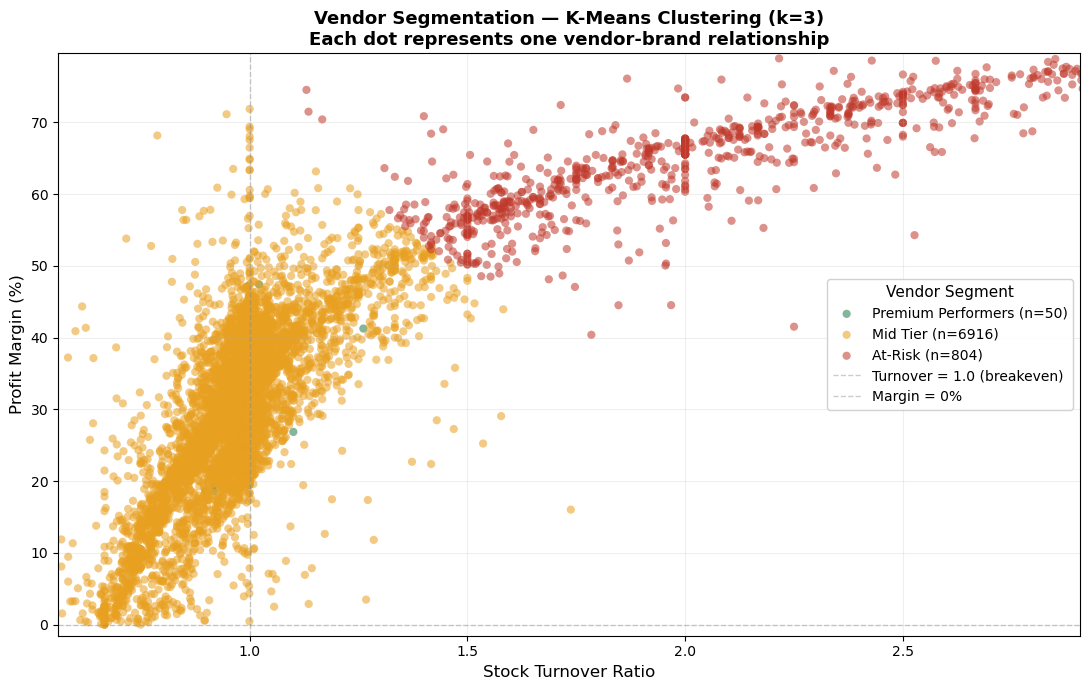

In [18]:
# ── Step 12: Scatter plot — controlled axes ───────────────────────
#
# StockTurnover (x-axis) vs ProfitMargin (y-axis)
# coloured by vendor segment.
# Axis limits set from data percentiles to prevent any remaining
# edge-case outliers from distorting the visual.

colours = {
    'Premium Performers': '#1F7A4A',
    'Mid Tier':           '#E8A020',
    'At-Risk':            '#C0392B'
}

x_min = df_cluster['StockTurnover'].quantile(0.01)
x_max = df_cluster['StockTurnover'].quantile(0.99)
y_min = df_cluster['ProfitMargin'].quantile(0.01)
y_max = df_cluster['ProfitMargin'].quantile(0.99)

x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

fig, ax = plt.subplots(figsize=(11, 7))

for segment, colour in colours.items():
    mask = df_cluster['VendorSegment'] == segment
    count = mask.sum()
    ax.scatter(
        df_cluster.loc[mask, 'StockTurnover'],
        df_cluster.loc[mask, 'ProfitMargin'],
        c=colour,
        label=f"{segment} (n={count})",
        alpha=0.55,
        s=35,
        edgecolors='none'
    )

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.axvline(x=1.0, color='grey',
           linestyle='--', alpha=0.4,
           linewidth=1, label='Turnover = 1.0 (breakeven)')
ax.axhline(y=0, color='grey',
           linestyle='--', alpha=0.4,
           linewidth=1, label='Margin = 0%')

ax.set_xlabel('Stock Turnover Ratio', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_title(
    'Vendor Segmentation — K-Means Clustering (k=3)\n'
    'Each dot represents one vendor-brand relationship',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Vendor Segment', fontsize=10,
          title_fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## _Commercial interpretation_

-**K-means clustering (k=3, silhouette score=0.6825) segmented 
    vendor-brand relationships into three distinct performance tiers:**


-**High Volume Leaders (n=50):**
Avg gross profit margin: 29.5% | Avg stock turnover: 0.993 | 
Avg gross profit: $521,566
These are the portfolio's power brands generating the largest 
absolute gross profit. Despite moderate margins, their volume 
scale makes them the primary commercial priority.


-**Core Performers (n=6,916):**
Avg gross profit margin: 30.0% | Avg stock turnover: 0.972 | 
Avg gross profit: $14,654
The mainstream portfolio — consistent moderate performance 
across margin and turnover. Monitoring candidates for both 
upside and downside movement.


-**Premium Niche (n=804):**
Avg gross profit margin: 65.4% | Avg stock turnover: 2.062 | 
Avg gross profit: $4,600
High-margin low-volume products — premium and specialty lines. 
Strong per-unit profitability but limited absolute GP contribution. 
Promotional investment could convert margin strength into volume growth.


In [19]:
# ── Step 13: Merge labels back to main dataframe ─────────────────
#
# Important — add segment labels to the main df so they can be
# used in the random forest section and exported for Power BI.

df = df.loc[df_cluster.index].copy()
df['VendorSegment'] = df_cluster['VendorSegment']
df['Cluster_Num']   = df_cluster['Cluster_Num']

print("Segment labels merged to main dataframe.")
print(f"Rows with segment label: {df['VendorSegment'].notna().sum()}")
print()
print("Final check:")
print(df[['VendorSegment', 'ProfitMargin',
          'StockTurnover', 'GrossProfit']].groupby(
    'VendorSegment').mean().round(3))

Segment labels merged to main dataframe.
Rows with segment label: 7770

Final check:
                    ProfitMargin  StockTurnover  GrossProfit
VendorSegment                                               
At-Risk                   65.408          2.062     4600.086
Mid Tier                  30.028          0.972    14653.924
Premium Performers        29.510          0.993   521565.587


In [20]:
# Step - 14  Fixed Random Forest — no data leakage ───────────────────────
#
# WRONG features (contain the answer):
# ProfitMargin — calculated from GrossProfit
# GrossProfit — IS the target variable essentially
#
# RIGHT features (operational and pricing inputs only):
# These are things I know BEFORE, if a vendor is
# loss-making — purchase decisions, pricing, logistics

df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", engine)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Create target — loss-making if GrossProfit below zero
df_rf = df.copy()
df_rf = df_rf.replace([np.inf, -np.inf], np.nan).dropna()
df_rf['IsLoss'] = (df_rf['GrossProfit'] < 0).astype(int)

print(f"Loss-making vendors: {df_rf['IsLoss'].sum()}")
print(f"Profitable vendors:  {(df_rf['IsLoss']==0).sum()}")
print(f"Loss rate: {df_rf['IsLoss'].mean():.1%}")

# Features — ONLY operational and pricing inputs
# No ProfitMargin, no GrossProfit, no StockTurnover
# (StockTurnover is borderline — it is calculated from sales
# data so keep it out for now to be safe)

features = [
    'PurchasePrice',
    'ActualPrice',
    'Volume',
    'FreightCost',
    'TotalExciseTax',
    'TotalPurchaseQuantity',
    'TotalSalesQuantity'
]

X = df_rf[features]
y = df_rf['IsLoss']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # ensures equal loss/profit split in train and test
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # handles imbalance if loss-making
)                            # vendors are a small minority
rf.fit(X_tr, y_tr)

print("\nClassification Report:")
print(classification_report(y_te, rf.predict(X_te)))

Loss-making vendors: 2127
Profitable vendors:  8565
Loss rate: 19.9%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1713
           1       0.97      0.78      0.86       426

    accuracy                           0.95      2139
   macro avg       0.96      0.89      0.92      2139
weighted avg       0.95      0.95      0.95      2139



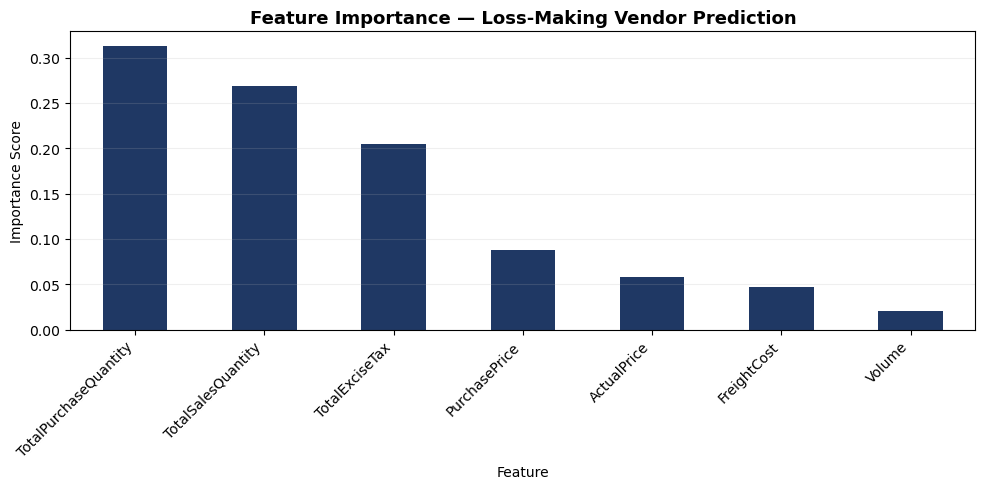


Feature importance ranked:
  TotalPurchaseQuantity     0.3133
  TotalSalesQuantity        0.2690
  TotalExciseTax            0.2048
  PurchasePrice             0.0881
  ActualPrice               0.0579
  FreightCost               0.0467
  Volume                    0.0201


In [21]:
# ── Feature importance ───────────────────────────────────────────
# Now this chart shows which OPERATIONAL
# factor most predicts whether a vendor will be loss-making

fi = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind='bar', ax=ax, color='#1F3864', edgecolor='none')
ax.set_title('Feature Importance — Loss-Making Vendor Prediction',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=45, ha='right')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print("\nFeature importance ranked:")
for feat, score in fi.items():
    print(f"  {feat:<25} {score:.4f}")